<a href="https://colab.research.google.com/github/rajakchhavi1-prog/sales---time-series/blob/main/demand_forcasting_using_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet
from prophet import Prophet

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv("/content/sample_data/train.csv", parse_dates=["Date"])
store = pd.read_csv("/content/sample_data/store.csv")

df = train.merge(store, on="Store", how="left")

In [ ]:
store_1 = df[df["Store"] == 1].copy()
store_1 = store_1.sort_values("Date")
store_1["Date"] = pd.to_datetime(store_1["Date"])
store_1.set_index("Date", inplace=True)

train_size = int(len(store_1) * 0.8)
train_data = store_1.iloc[:train_size]
test_data = store_1.iloc[train_size:]

In [ ]:
print(train_data.shape)

(753, 17)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_data["Sales"], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.get_forecast(steps=len(test_data))
forecast_values = forecast.predicted_mean

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data["Sales"], forecast_values)
rmse = np.sqrt(mean_squared_error(test_data["Sales"], forecast_values))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1299.2397093393452
RMSE: 1926.0550920470716


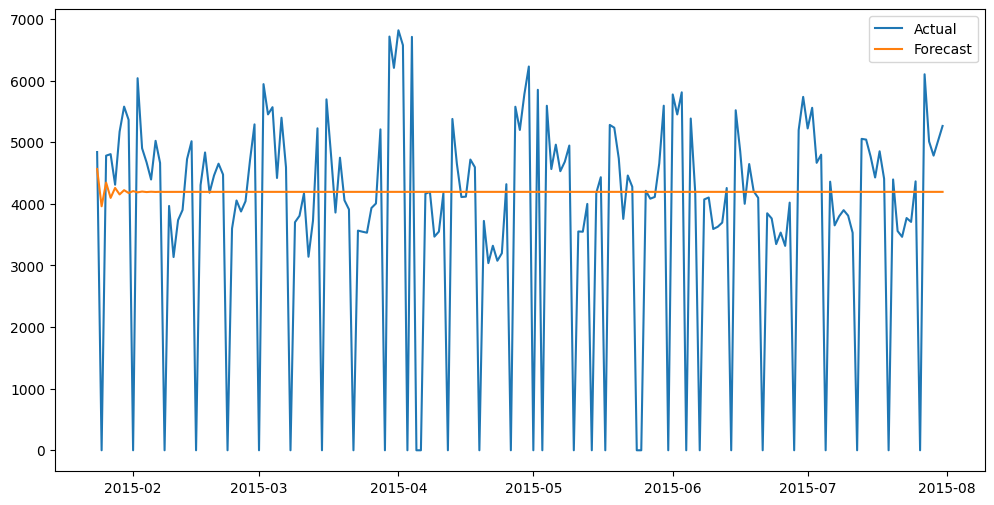

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data["Sales"], label="Actual")
plt.plot(test_data.index, forecast_values, label="Forecast")
plt.legend()
plt.show()

In [ ]:
#prophet model

prophet_df = store_1.reset_index()[["Date", "Sales"]]
prophet_df.columns = ["ds", "y"]

In [ ]:
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [ ]:
model_prophet = Prophet()
model_prophet.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet))
forecast_prophet = model_prophet.predict(future)

In [ ]:
forecast_values = forecast_prophet["yhat"].iloc[train_size:]

In [ ]:
mae_p = mean_absolute_error(test_prophet["y"], forecast_values)
rmse_p = np.sqrt(mean_squared_error(test_prophet["y"], forecast_values))

print("Prophet MAE:", mae_p)
print("Prophet RMSE:", rmse_p)

Prophet MAE: 701.4997645601529
Prophet RMSE: 1084.1093848505989


In [ ]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [mae, mae_p],
    "RMSE": [rmse, rmse_p]
})

print(results)

     Model          MAE         RMSE
0    ARIMA  1299.239709  1926.055092
1  Prophet   701.499765  1084.109385


In [ ]:
# weekly seasonality analysis

# add weekday column

store_1["Weekday"] = store_1.index.day_name()

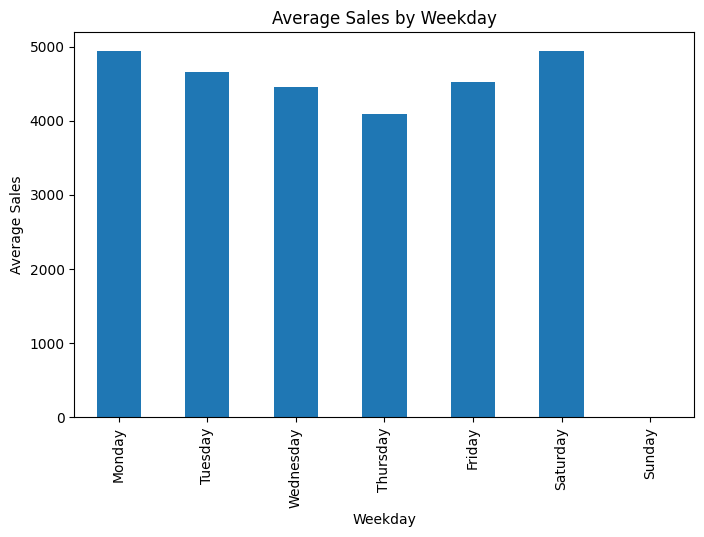

In [ ]:
# average sales by weekdayy

#Sales peak on weekends → strong weekly seasonality present.

weekday_sales = store_1.groupby("Weekday")["Sales"].mean()

weekday_sales = weekday_sales.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(8,5))
weekday_sales.plot(kind="bar")
plt.title("Average Sales by Weekday")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
#Promotion Impact Analysis
#Average Sales: Promo vs No Promo
promo_sales = store_1.groupby("Promo")["Sales"].mean()
print(promo_sales)


Promo
0    3198.994845
1    5152.886111
Name: Sales, dtype: float64


In [ ]:
uplift = ((promo_sales[1] - promo_sales[0]) / promo_sales[0]) * 100
print("Promotion Uplift (%):", uplift)

Promotion Uplift (%): 61.078287405927355


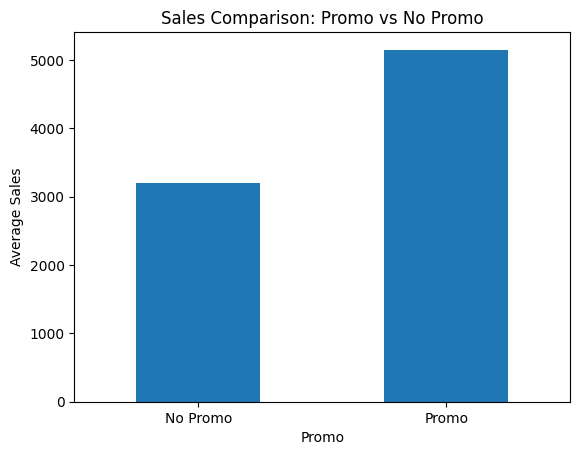

In [ ]:
promo_sales.plot(kind="bar")
plt.xticks([0,1], ["No Promo", "Promo"], rotation=0)
plt.title("Sales Comparison: Promo vs No Promo")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# ARIMAX (ARIMA with Promo as External Variable)

train_exog = train_data[["Promo"]]
test_exog = test_data[["Promo"]]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_arimax = SARIMAX(
    train_data["Sales"],
    order=(5,1,0),
    exog=train_exog
)

model_arimax_fit = model_arimax.fit()

In [ ]:
forecast_arimax = model_arimax_fit.forecast(
    steps=len(test_data),
    exog=test_exog
)

In [ ]:
mae_arimax = mean_absolute_error(test_data["Sales"], forecast_arimax)
rmse_arimax = np.sqrt(mean_squared_error(test_data["Sales"], forecast_arimax))

print("ARIMAX MAE:", mae_arimax)
print("ARIMAX RMSE:", rmse_arimax)

ARIMAX MAE: 1571.2687470278156
ARIMAX RMSE: 2119.1260045133627


In [ ]:
#Prophet with Promotion Regressor
# prepare data

prophet_df = store_1.reset_index()[["Date", "Sales", "Promo"]]
prophet_df.columns = ["ds", "y", "promo"]

In [ ]:
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [ ]:
model_prophet = Prophet()
model_prophet.add_regressor("promo")

model_prophet.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet))
future["promo"] = prophet_df["promo"]

In [ ]:
forecast_prophet = model_prophet.predict(future)

forecast_values = forecast_prophet["yhat"].iloc[train_size:]

In [ ]:
mae_prophet_reg = mean_absolute_error(test_prophet["y"], forecast_values)
rmse_prophet_reg = np.sqrt(mean_squared_error(test_prophet["y"], forecast_values))

print("Prophet + Promo MAE:", mae_prophet_reg)
print("Prophet + Promo RMSE:", rmse_prophet_reg)

Prophet + Promo MAE: 558.3003798105102
Prophet + Promo RMSE: 953.1054864199713


In [ ]:
results = pd.DataFrame({
    "Model": ["ARIMA", "ARIMAX", "Prophet", "Prophet + Promo"],
    "MAE": [mae, mae_arimax, mae_p, mae_prophet_reg],
    "RMSE": [rmse, rmse_arimax, rmse_p, rmse_prophet_reg]
})

print(results)

             Model          MAE         RMSE
0            ARIMA  1299.239709  1926.055092
1           ARIMAX  1571.268747  2119.126005
2          Prophet   701.499765  1084.109385
3  Prophet + Promo   558.300380   953.105486
